### Importación de datos



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda1 = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tiendas = [tienda1, tienda2, tienda3, tienda4]
nombres = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
colores = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

print('Datos cargados correctamente.')
tienda1.head()

Datos cargados correctamente.


,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [2]:
# Cálculo de ingresos totales por tienda
ingresos = [t['Precio'].sum() for t in tiendas]

for nombre, ingreso in zip(nombres, ingresos):
    print(f'{nombre}: ${ingreso:,.0f}')

Tienda 1: $1,150,880,400
Tienda 2: $1,116,343,500
Tienda 3: $1,098,019,600
Tienda 4: $1,038,375,700


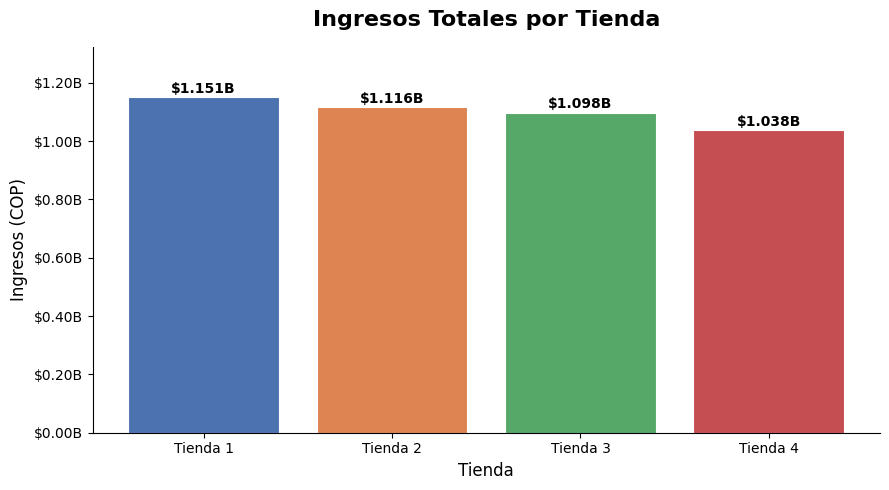

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(nombres, ingresos, color=colores, edgecolor='white', linewidth=0.8)
ax.set_title('Ingresos Totales por Tienda', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Tienda', fontsize=12)
ax.set_ylabel('Ingresos (COP)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e9:.2f}B'))
for bar, val in zip(bars, ingresos):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5e6,
            f'${val/1e9:.3f}B', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(0, max(ingresos) * 1.15)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# 2. Ventas por categoría

In [4]:
# Ventas por categoría en cada tienda
for nombre, tienda in zip(nombres, tiendas):
    cats = tienda['Categoría del Producto'].value_counts()
    print(f'\n{nombre}:')
    for cat, cnt in cats.items():
        print(f'  {cat}: {cnt} unidades')


Tienda 1:
  Muebles: 465 unidades
  Electrónicos: 448 unidades
  Juguetes: 324 unidades
  Electrodomésticos: 312 unidades
  Deportes y diversión: 284 unidades
  Instrumentos musicales: 182 unidades
  Libros: 173 unidades
  Artículos para el hogar: 171 unidades

Tienda 2:
  Muebles: 442 unidades
  Electrónicos: 422 unidades
  Juguetes: 313 unidades
  Electrodomésticos: 305 unidades
  Deportes y diversión: 275 unidades
  Instrumentos musicales: 224 unidades
  Libros: 197 unidades
  Artículos para el hogar: 181 unidades

Tienda 3:
  Muebles: 499 unidades
  Electrónicos: 451 unidades
  Juguetes: 315 unidades
  Electrodomésticos: 278 unidades
  Deportes y diversión: 277 unidades
  Libros: 185 unidades
  Instrumentos musicales: 177 unidades
  Artículos para el hogar: 177 unidades

Tienda 4:
  Muebles: 480 unidades
  Electrónicos: 451 unidades
  Juguetes: 338 unidades
  Deportes y diversión: 277 unidades
  Electrodomésticos: 254 unidades
  Artículos para el hogar: 201 unidades
  Libros: 187 

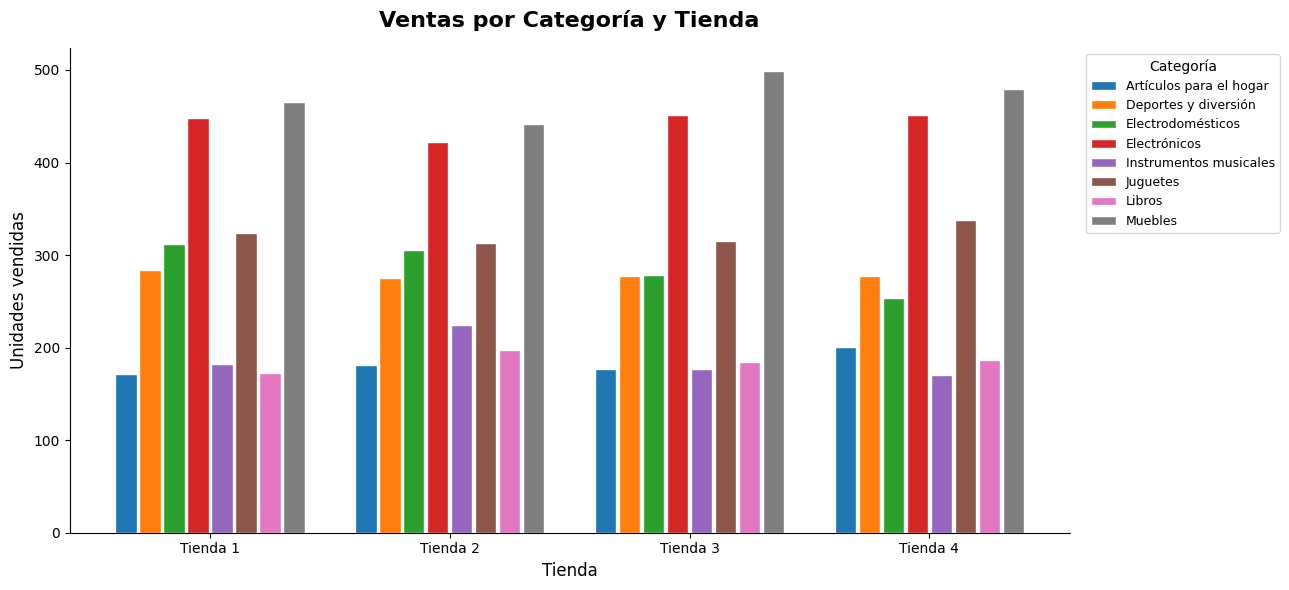

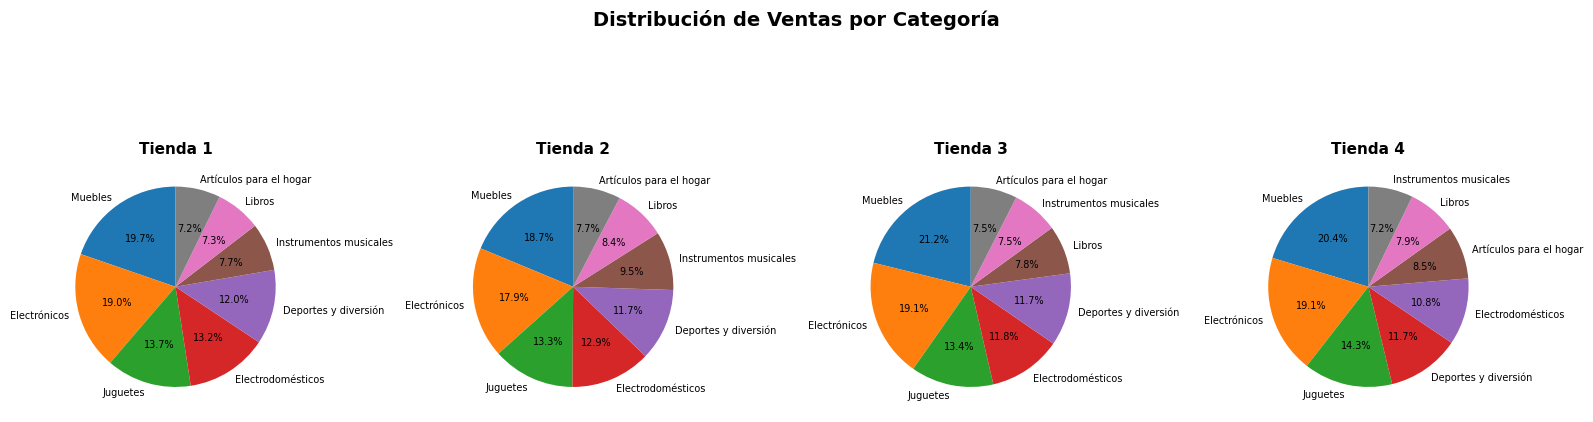

In [5]:
# Obtener todas las categorías únicas
todas_categorias = sorted(set(
    cat for t in tiendas for cat in t['Categoría del Producto'].unique()
))

# Construir matriz de ventas por categoría
ventas_cat = {}
for cat in todas_categorias:
    ventas_cat[cat] = [t['Categoría del Producto'].value_counts().get(cat, 0) for t in tiendas]

# Gráfico de barras agrupadas
x = range(len(nombres))
n_cats = len(todas_categorias)
width = 0.8 / n_cats
palette = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(13, 6))
for i, (cat, vals) in enumerate(ventas_cat.items()):
    offset = (i - n_cats / 2 + 0.5) * width
    ax.bar([xi + offset for xi in x], vals, width=width*0.9,
           label=cat, color=palette[i % len(palette)], edgecolor='white')

ax.set_title('Ventas por Categoría y Tienda', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Tienda', fontsize=12)
ax.set_ylabel('Unidades vendidas', fontsize=12)
ax.set_xticks(list(x))
ax.set_xticklabels(nombres)
ax.legend(title='Categoría', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# Gráfico circular para la tienda con menor ingreso (Tienda 4)
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, nombre, tienda in zip(axes, nombres, tiendas):
    counts = tienda['Categoría del Producto'].value_counts()
    ax.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
           startangle=90, textprops={'fontsize': 7},
           colors=plt.cm.tab10.colors[:len(counts)])
    ax.set_title(nombre, fontsize=11, fontweight='bold')
fig.suptitle('Distribución de Ventas por Categoría', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 3. Calificación promedio de la tienda


In [6]:
# Calificación promedio por tienda
calificaciones = [t['Calificación'].mean() for t in tiendas]

for nombre, cal in zip(nombres, calificaciones):
    print(f'{nombre}: {cal:.4f} ⭐')

Tienda 1: 3.9767 ⭐
Tienda 2: 4.0373 ⭐
Tienda 3: 4.0483 ⭐
Tienda 4: 3.9958 ⭐


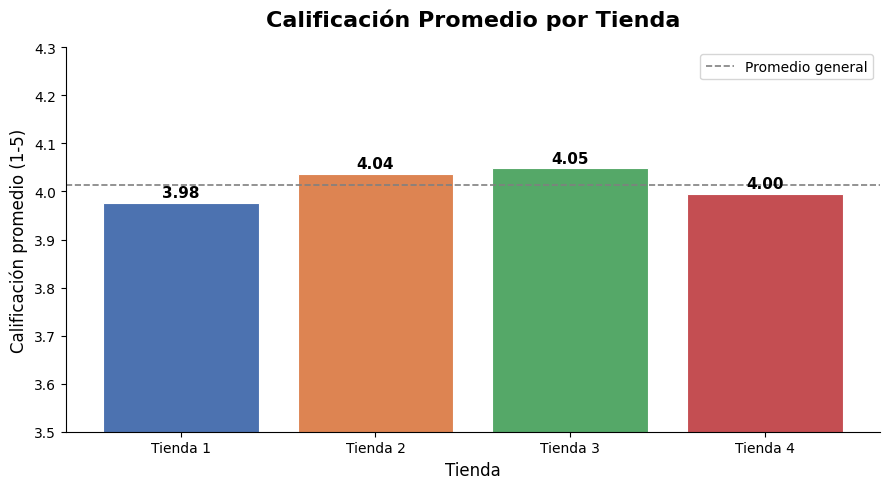

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(nombres, calificaciones, color=colores, edgecolor='white', linewidth=0.8)
ax.set_title('Calificación Promedio por Tienda', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Tienda', fontsize=12)
ax.set_ylabel('Calificación promedio (1-5)', fontsize=12)
ax.set_ylim(3.5, 4.3)
for bar, val in zip(bars, calificaciones):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.axhline(y=sum(calificaciones)/len(calificaciones), color='gray',
           linestyle='--', linewidth=1.2, label='Promedio general')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# 4. Productos más y menos vendidos

In [8]:
# Producto más y menos vendido por tienda
for nombre, tienda in zip(nombres, tiendas):
    conteo = tienda['Producto'].value_counts()
    print(f'\n{nombre}:')
    print(f'  Más vendido:  {conteo.index[0]} ({conteo.iloc[0]} ventas)')
    print(f'  Menos vendido: {conteo.index[-1]} ({conteo.iloc[-1]} ventas)')


Tienda 1:
  Más vendido:  Microondas (60 ventas)
  Menos vendido: Celular ABXY (33 ventas)

Tienda 2:
  Más vendido:  Iniciando en programación (65 ventas)
  Menos vendido: Juego de mesa (32 ventas)

Tienda 3:
  Más vendido:  Kit de bancas (57 ventas)
  Menos vendido: Bloques de construcción (35 ventas)

Tienda 4:
  Más vendido:  Cama box (62 ventas)
  Menos vendido: Guitarra eléctrica (33 ventas)


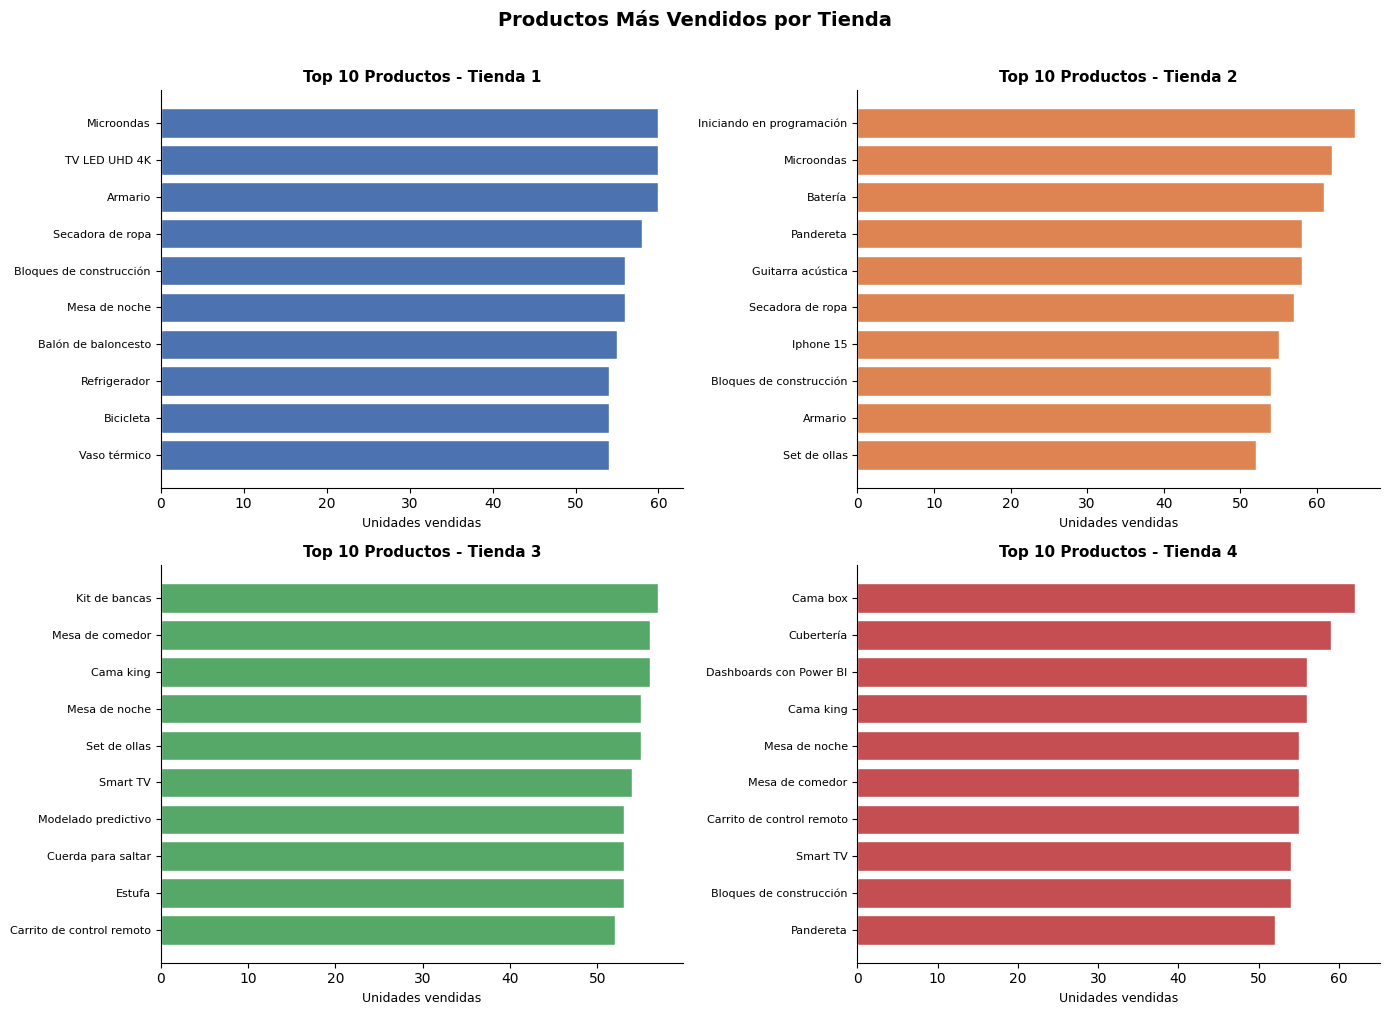

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, nombre, tienda, color in zip(axes, nombres, tiendas, colores):
    top10 = tienda['Producto'].value_counts().head(10)
    ax.barh(top10.index[::-1], top10.values[::-1], color=color, edgecolor='white')
    ax.set_title(f'Top 10 Productos - {nombre}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Unidades vendidas', fontsize=9)
    ax.tick_params(axis='y', labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Productos Más Vendidos por Tienda', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# 5. Envío promedio por tienda

In [10]:
# Costo de envío promedio por tienda
envios = [t['Costo de envío'].mean() for t in tiendas]

for nombre, envio in zip(nombres, envios):
    print(f'{nombre}: ${envio:,.0f}')

Tienda 1: $26,019
Tienda 2: $25,216
Tienda 3: $24,806
Tienda 4: $23,459


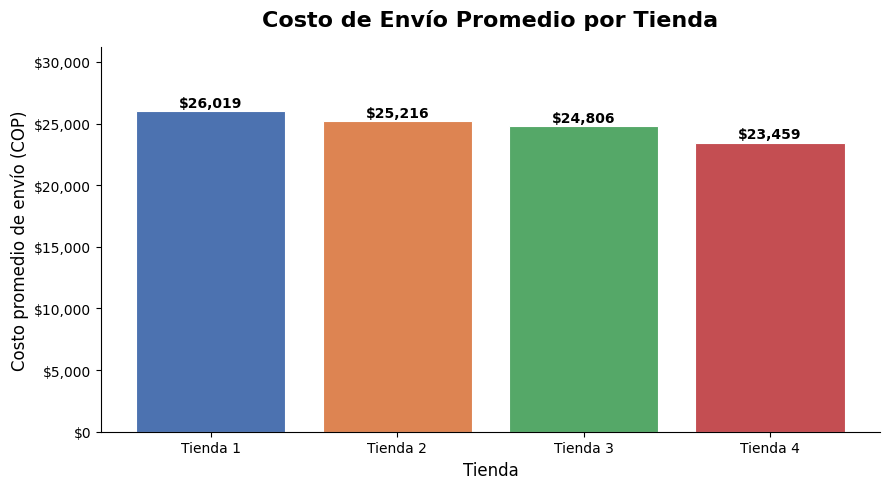

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(nombres, envios, color=colores, edgecolor='white', linewidth=0.8)
ax.set_title('Costo de Envío Promedio por Tienda', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Tienda', fontsize=12)
ax.set_ylabel('Costo promedio de envío (COP)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, val in zip(bars, envios):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(0, max(envios) * 1.2)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# 6. Recomendación Final

In [12]:
# Resumen comparativo de todas las métricas
import pandas as pd

resumen = pd.DataFrame({
    'Tienda': nombres,
    'Ingresos Totales (COP)': [f'${v:,.0f}' for v in ingresos],
    'Calificación Promedio': [f'{v:.2f}' for v in calificaciones],
    'Envío Promedio (COP)': [f'${v:,.0f}' for v in envios],
})
resumen

,Tienda,Ingresos Totales (COP),Calificación Promedio,Envío Promedio (COP)
0,Tienda 1,"$1,150,880,400",3.98,"$26,019"
1,Tienda 2,"$1,116,343,500",4.04,"$25,216"
2,Tienda 3,"$1,098,019,600",4.05,"$24,806"
3,Tienda 4,"$1,038,375,700",4.00,"$23,459"


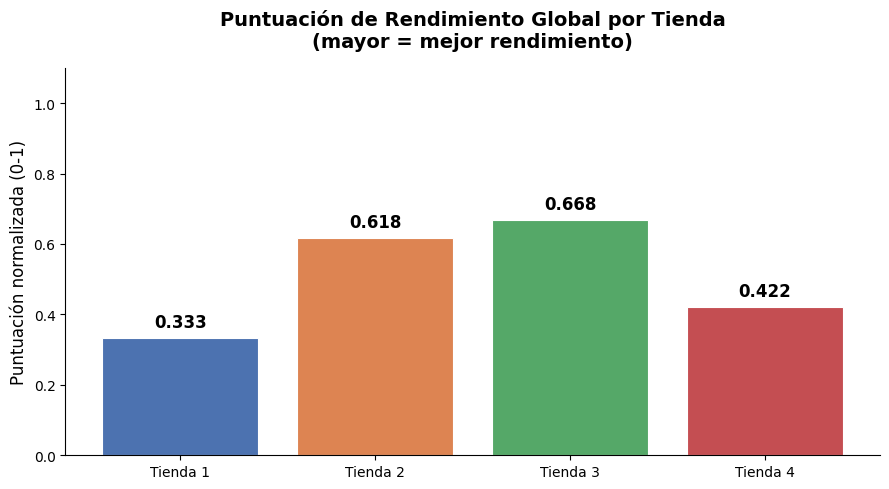


Tienda con menor rendimiento: Tienda 1 (score: 0.333)


In [13]:
# Gráfico radar / comparativo final
import numpy as np

# Normalizar métricas (0=peor, 1=mejor)
def norm(vals, higher_is_better=True):
    mn, mx = min(vals), max(vals)
    if mx == mn:
        return [0.5] * len(vals)
    normalized = [(v - mn) / (mx - mn) for v in vals]
    return normalized if higher_is_better else [1 - n for n in normalized]

n_ingresos    = norm(ingresos, higher_is_better=True)
n_calificacion = norm(calificaciones, higher_is_better=True)
n_envio       = norm(envios, higher_is_better=False)  # menor costo = mejor

scores = [round((a + b + c) / 3, 4) for a, b, c in zip(n_ingresos, n_calificacion, n_envio)]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(nombres, scores, color=colores, edgecolor='white', linewidth=0.8)
ax.set_title('Puntuación de Rendimiento Global por Tienda\n(mayor = mejor rendimiento)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Puntuación normalizada (0-1)', fontsize=12)
ax.set_ylim(0, 1.1)
for bar, val in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

peor_idx = scores.index(min(scores))
print(f'\nTienda con menor rendimiento: {nombres[peor_idx]} (score: {scores[peor_idx]:.3f})')

## Recomendación Final

Después de analizar las cuatro tiendas de Alura Store en cinco dimensiones clave (ingresos totales, ventas por categoría, calificaciones de clientes, productos más vendidos y costos de envío), se recomienda que el **Sr. Juan venda la Tienda 4**.

### Justificación basada en datos:

| Métrica | Tienda 1 | Tienda 2 | Tienda 3 | Tienda 4 |
|---------|----------|----------|----------|----------|
| Ingresos Totales | $1,150,880,400 | $1,116,343,500 | $1,098,019,600 | **$1,038,375,700** |
| Calificación Promedio | 3.98 | 4.04 | 4.05 | 4.00 |
| Costo Envío Promedio | $26,019 | $25,216 | $24,806 | $23,459 |

**Razones principales:**

1. 🔴 **Ingresos más bajos**: La Tienda 4 genera los menores ingresos totales ($1,038,375,700), aproximadamente **$112 millones menos** que la Tienda 1 (la más rentable). Esta diferencia representa una brecha significativa en rentabilidad.

2. 🟡 **Calificación media**: Con un promedio de **4.00 estrellas**, la Tienda 4 se sitúa por debajo de Tienda 2 (4.04) y Tienda 3 (4.05), aunque supera ligeramente a Tienda 1 (3.98). La satisfacción del cliente es mejorable.

3. 🟢 **Ventaja en envíos**: El costo de envío promedio más bajo ($23,459) es un punto positivo, pero no compensa el déficit en ingresos y no se traduce en mayor volumen de ventas.

4. 📊 **Rendimiento global más bajo**: Al combinar todas las métricas en una puntuación normalizada de rendimiento, la **Tienda 4 obtiene la puntuación más baja**, confirmando que es la menos eficiente de la cadena.

**Conclusión**: La Tienda 4 es la candidata ideal para ser vendida, ya que presenta el rendimiento financiero más débil. Los recursos obtenidos con la venta pueden ser reinvertidos por el Sr. Juan en su nuevo emprendimiento con mejor proyección de retorno.